# Hybrid Model Training — ConvNeXt-Base & Swin-Base

Training hybrid models on **ISIC 2019** for skin lesion classification.

**Models:**
- ConvNeXt-Base (CNN with Transformer design principles — Meta, 2022)
- Swin-Base (Shifted Window Transformer — Liu et al., 2021)

**Anti-overfitting strategy** (paper: Anaissi et al. 2026 + model-specific best practices):

| Technique | ConvNeXt | Swin | Source |
|---|:---:|:---:|---|
| Focal Loss (γ=2.0) | ✅ | ✅ | Paper |
| Label Smoothing (0.1) | ✅ | ✅ | Standard |
| Mixup Augmentation (α=0.2) | ✅ | ✅ | Standard |
| Stochastic Depth (drop_path=0.1) | ✅ | ✅ | timm |
| AdamW + selective weight decay | ✅ | ✅ | Transformer standard |
| Linear Warmup → Cosine LR | ✅ | ✅ | Transformer standard |
| Strong augmentation (elastic deform) | ✅ | ✅ | Paper |
| WeightedRandomSampler | ✅ | ✅ | Paper |
| Gradient Clipping (max=1.0) | ✅ | ✅ | Standard |
| Early Stopping (patience=15) | ✅ | ✅ | Standard |
| **BatchFormer** (cross-sample attention) | ❌ | ✅ | **Paper (Swin only)** |

In [1]:
!pip install PyDrive2
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

## 0. Download & Prepare ISIC 2019 Dataset (Kaggle / Colab)

In [3]:
import os
import requests
import zipfile

# ---------------------------------------
# Base directory (adjust for Colab: /content/xai_medical_imaging/data/ISIC2019)
# ---------------------------------------
base_dir = "/kaggle/working/xai_medical_imaging/data/ISIC2019"
os.makedirs(base_dir, exist_ok=True)

# ---------------------------------------
# URLs
# ---------------------------------------
urls = {
    "train_zip": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_Input.zip",
    "train_csv": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv",
    "test_zip":  "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_Input.zip",
    "test_csv":  "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv",
}

def download(url, dest):
    print(f"Downloading {dest} ...")
    r = requests.get(url)
    with open(dest, "wb") as f:
        f.write(r.content)
    print(f"✔ Done.")

def extract_and_remove(zip_path, extract_to):
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_to)
    print("✔ Extracted.")
    os.remove(zip_path)
    print(f"✔ Removed {zip_path}.")

# STEP 1 — Training dataset
train_zip_path = f"{base_dir}/ISIC_2019_Training_Input.zip"
download(urls["train_zip"], train_zip_path)
extract_and_remove(train_zip_path, base_dir)
download(urls["train_csv"], f"{base_dir}/ISIC_2019_Training_GroundTruth.csv")

# STEP 2 — Test dataset
test_zip_path = f"{base_dir}/ISIC_2019_Test_Input.zip"
download(urls["test_zip"], test_zip_path)
extract_and_remove(test_zip_path, base_dir)
download(urls["test_csv"], f"{base_dir}/ISIC_2019_Test_GroundTruth.csv")

print("\n✔ Dataset fully downloaded, extracted, and cleaned.")

✔ Done.
Extracting /kaggle/working/xai_medical_imaging/data/ISIC2019/ISIC_2019_Training_Input.zip ...
✔ Extracted.
✔ Removed /kaggle/working/xai_medical_imaging/data/ISIC2019/ISIC_2019_Training_Input.zip.
✔ Done.
✔ Done.
Extracting /kaggle/working/xai_medical_imaging/data/ISIC2019/ISIC_2019_Test_Input.zip ...
✔ Extracted.
✔ Removed /kaggle/working/xai_medical_imaging/data/ISIC2019/ISIC_2019_Test_Input.zip.
✔ Done.

✔ Dataset fully downloaded, extracted, and cleaned.


## 1. Setup & Dependencies

In [2]:
# ============================================================
# 1. SETUP & DEPENDENCIES
# ============================================================

import os, sys

ON_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
ON_COLAB  = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if ON_KAGGLE:
    os.system('rm -rf /kaggle/working/xai_medical_imaging')
    os.system('git clone https://github.com/youssef-nouiouar/xai_medical_imaging.git /kaggle/working/xai_medical_imaging')
    REPO_ROOT = '/kaggle/working/xai_medical_imaging'
elif ON_COLAB:
    os.system('git clone https://github.com/youssef-nouiouar/xai_medical_imaging.git /content/xai_medical_imaging')
    REPO_ROOT = '/content/xai_medical_imaging'
else:
    REPO_ROOT = os.path.abspath('..')

sys.path.insert(0, REPO_ROOT)

# --- Install dependencies (uncomment if needed) ---
# !pip install timm==0.9.12 albumentations==1.3.1 scikit-learn pandas matplotlib seaborn tqdm

import copy, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   Memory : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("✔ All dependencies loaded.")

Cloning into '/kaggle/working/xai_medical_imaging'...


Device : cuda
   GPU    : Tesla T4
   Memory : 15.6 GB
✔ All dependencies loaded.


## 2. Configuration

In [4]:
# ============================================================
# 2. CONFIGURATION — Hybrid Models Anti-Overfitting Strategy
# ============================================================
# ConvNeXt-Base uses the same training recipe as ViT (AdamW,
# cosine schedule, drop_path, mixup) — designed by Meta to match ViT.
# Swin-Base uses the same recipe + BatchFormer (paper-specific).
# ============================================================

# --- Paths ---
DATA_DIR = '/kaggle/working/xai_medical_imaging/data/ISIC2019'   # Kaggle
SAVE_DIR = '/kaggle/working/xai_medical_imaging/results'
# DATA_DIR = '/content/xai_medical_imaging/data/ISIC2019'        # Colab
# DATA_DIR = '../data/ISIC2019'                                   # Local
# SAVE_DIR = '../results'                                         # Local

os.makedirs(SAVE_DIR, exist_ok=True)

# --- Dataset ---
IMAGE_SIZE  = 224
NUM_CLASSES = 8
VAL_RATIO   = 0.25
NUM_WORKERS = 2

# --- Training ---
BATCH_SIZE    = 32
EPOCHS        = 100
LR            = 1e-4
WEIGHT_DECAY  = 0.05
PATIENCE      = 10
WARMUP_EPOCHS = 5
GRAD_CLIP     = 1.0

# --- Anti-overfitting ---
DROP_PATH_RATE  = 0.1
LABEL_SMOOTHING = 0.1
FOCAL_GAMMA     = 2.0
MIXUP_ALPHA     = 0.2

# --- Class names ---
CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
CLASS_NAMES_FULL = {
    'MEL': 'Melanoma',              'NV': 'Naevus melanocytaire',
    'BCC': 'Carcinome basocellulaire', 'AK': 'Kératose actinique',
    'BKL': 'Kératose bénigne',      'DF': 'Dermatofibrome',
    'VASC': 'Lésion vasculaire',    'SCC': 'Carcinome épidermoïde',
}

print("Hybrid Configuration:")
for k, v in {
    "Image size": f"{IMAGE_SIZE}×{IMAGE_SIZE}", "Batch size": BATCH_SIZE,
    "Epochs": EPOCHS,               "LR (AdamW)": LR,
    "Weight decay": WEIGHT_DECAY,   "Warmup epochs": WARMUP_EPOCHS,
    "Drop path rate": DROP_PATH_RATE, "Label smoothing": LABEL_SMOOTHING,
    "Focal γ": FOCAL_GAMMA,         "Mixup α": MIXUP_ALPHA,
    "Val ratio": VAL_RATIO,         "Num classes": NUM_CLASSES,
}.items():
    print(f"   {k:22s}: {v}")

Hybrid Configuration:
   Image size            : 224×224
   Batch size            : 32
   Epochs                : 100
   LR (AdamW)            : 0.0001
   Weight decay          : 0.05
   Warmup epochs         : 5
   Drop path rate        : 0.1
   Label smoothing       : 0.1
   Focal γ               : 2.0
   Mixup α               : 0.2
   Val ratio             : 0.25
   Num classes           : 8


## 3. Dataset & DataLoaders

In [5]:
# ============================================================
# 3. DATASET & DATALOADERS
# ============================================================
# Same strategy as train_vit:
#   - ISICDataset 'strong' augmentation (elastic deform, color jitter,
#     CoarseDropout, GaussNoise, GridDistortion)
#   - WeightedRandomSampler to correct class imbalance
# ============================================================

from data.isic_dataset import ISICDataset

train_dataset = ISICDataset(
    root_dir=DATA_DIR, split='train',
    image_size=IMAGE_SIZE,
    use_albumentations=True,
    augmentation_strength='strong',
    use_official_test=True,
    val_ratio=VAL_RATIO,
)
val_dataset = ISICDataset(
    root_dir=DATA_DIR, split='val',
    image_size=IMAGE_SIZE,
    use_albumentations=True,
    use_official_test=True,
    val_ratio=VAL_RATIO,
)

class_counts = Counter(train_dataset.labels)
total_train  = len(train_dataset)
print(f"Train: {total_train} images | Val: {len(val_dataset)} images\n")
print("Class distribution (train):")
for i, name in enumerate(CLASS_NAMES):
    cnt = class_counts.get(i, 0)
    bar = '█' * (cnt // 500)
    print(f"   {name:5s}: {cnt:>5d}  ({cnt/total_train*100:.1f}%)  {bar}")

# WeightedRandomSampler
class_weights  = torch.tensor(
    [total_train / (NUM_CLASSES * max(class_counts[i], 1)) for i in range(NUM_CLASSES)],
    dtype=torch.float)
sample_weights = class_weights[train_dataset.labels]
sampler        = WeightedRandomSampler(sample_weights, num_samples=total_train, replacement=True)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=True,
)
print(f"\n✔ DataLoaders ready | Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train: 18998 images | Val: 6333 images

Class distribution (train):
   MEL  :  3392  (17.9%)  ██████
   NV   :  9656  (50.8%)  ███████████████████
   BCC  :  2492  (13.1%)  ████
   AK   :   650  (3.4%)  █
   BKL  :  1968  (10.4%)  ███
   DF   :   179  (0.9%)  
   VASC :   190  (1.0%)  
   SCC  :   471  (2.5%)  

✔ DataLoaders ready | Train batches: 593 | Val batches: 198


## 4. Model Architecture

In [22]:
# ============================================================
# 4a. MODEL A — ConvNeXt-Base
# ============================================================
# ConvNeXt was designed by Meta (2022) to match ViT performance
# using pure convolutions + Transformer design principles:
#   - Depthwise convolutions, LayerNorm, GELU, inverted bottleneck
#   - Same training recipe as ViT: AdamW, cosine LR, mixup, drop_path
# Feature dim: 1024  |  drop_path_rate: stochastic depth
# ============================================================

def build_convnext_base(num_classes=NUM_CLASSES, pretrained=True,
                        drop_path_rate=DROP_PATH_RATE):
    model = timm.create_model(
        'convnext_base',
        pretrained=pretrained,
        num_classes=num_classes,
        drop_path_rate=drop_path_rate,
    )
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"ConvNeXt-Base (pretrained={pretrained}, drop_path_rate={drop_path_rate})")
    print(f"  Classifier      : {model.get_classifier()}")
    print(f"  Feature dim     : {model.num_features}")
    print(f"  Total params    : {total:,}")
    print(f"  Trainable params: {trainable:,}")
    return model

_m = build_convnext_base()
_o = _m(torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE))
print(f"  Output shape    : {_o.shape}  (expected: [2, {NUM_CLASSES}])")
del _m, _o
torch.cuda.empty_cache()
print("✔ ConvNeXt-Base architecture verified.")

model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

ConvNeXt-Base (pretrained=True, drop_path_rate=0.1)
  Classifier      : Linear(in_features=1024, out_features=8, bias=True)
  Feature dim     : 1024
  Total params    : 87,574,664
  Trainable params: 87,574,664
  Output shape    : torch.Size([2, 8])  (expected: [2, 8])
✔ ConvNeXt-Base architecture verified.


In [6]:
# ============================================================
# 4b. MODEL B — Swin-Base + BatchFormer
# ============================================================
# Swin Transformer (Liu et al., 2021):
#   - Hierarchical design with shifted window attention
#   - Efficient multi-scale feature extraction
#   - Feature dim: 1024
#
# BatchFormer (paper: Anaissi et al. 2026):
#   - Applies self-attention ACROSS the batch dimension
#   - Each sample attends to all other samples in the mini-batch
#   - Enables cross-sample gradient propagation:
#       majority class samples help train minority class representations
#   - Acts as virtual data augmentation for underrepresented classes
#   - Only meaningful during training; applied at inference too (fine)
# ============================================================

class BatchFormerBlock(nn.Module):
    """
    Cross-sample self-attention over the batch dimension.
    Input:  (B, d)  — pooled feature vectors
    Output: (B, d)  — enriched by inter-sample attention
    """
    def __init__(self, d_model, nhead=8, dropout=0.1):
        super().__init__()
        # Ensure d_model is divisible by nhead
        while nhead > 1 and d_model % nhead != 0:
            nhead -= 1
        self.attn  = nn.MultiheadAttention(d_model, nhead, dropout=dropout,
                                            batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (B, d) → treat entire batch as one sequence of length B
        # MultiheadAttention (batch_first=True): input shape (batch, seq, embed)
        # → wrap as (1, B, d): batch=1, seq=B
        x_seq    = x.unsqueeze(0)                    # (1, B, d)
        attn_out, _ = self.attn(x_seq, x_seq, x_seq) # (1, B, d)
        x_out    = self.norm1(x + attn_out.squeeze(0))  # (B, d)
        x_out    = self.norm2(x_out + self.ff(x_out))   # (B, d)
        return x_out


class SwinWithBatchFormer(nn.Module):
    """Swin-Base backbone + BatchFormer + linear classifier."""

    def __init__(self, num_classes=NUM_CLASSES, pretrained=True,
                 drop_path_rate=DROP_PATH_RATE):
        super().__init__()
        # Backbone: Swin-Base without classification head
        self.backbone = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0,             # remove head → returns pooled features
            drop_path_rate=drop_path_rate,
        )
        in_features = self.backbone.num_features   # 1024

        # BatchFormer: cross-sample attention (paper, Sec. 3.2)
        self.batch_former = BatchFormerBlock(d_model=in_features)

        # Final classifier
        self.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)            # (B, 1024)
        features = self.batch_former(features) # (B, 1024) — cross-sample attention
        return self.head(features)             # (B, num_classes)


def build_swin_base(num_classes=NUM_CLASSES, pretrained=True,
                    drop_path_rate=DROP_PATH_RATE):
    model     = SwinWithBatchFormer(num_classes, pretrained, drop_path_rate)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    in_feat   = model.backbone.num_features
    print(f"Swin-Base + BatchFormer (pretrained={pretrained}, drop_path={drop_path_rate})")
    print(f"  Feature dim     : {in_feat}")
    print(f"  BatchFormer dim : {in_feat}")
    print(f"  Total params    : {total:,}")
    print(f"  Trainable params: {trainable:,}")
    return model

_m = build_swin_base()
_o = _m(torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE))
print(f"  Output shape    : {_o.shape}  (expected: [2, {NUM_CLASSES}])")
del _m, _o
torch.cuda.empty_cache()
print("✔ Swin-Base + BatchFormer architecture verified.")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Swin-Base + BatchFormer (pretrained=True, drop_path=0.1)
  Feature dim     : 1024
  BatchFormer dim : 1024
  Total params    : 99,347,648
  Trainable params: 99,347,648
  Output shape    : torch.Size([2, 8])  (expected: [2, 8])
✔ Swin-Base + BatchFormer architecture verified.


## 5. Training Loop

In [7]:
# ============================================================
# 5. TRAINING LOOP
# ============================================================
# Identical pipeline for ConvNeXt and Swin (BatchFormer is
# already embedded inside SwinWithBatchFormer.forward()).
# ============================================================

# --- Focal Loss + Label Smoothing ---
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING,
                 num_classes=NUM_CLASSES):
        super().__init__()
        self.gamma          = gamma
        self.label_smoothing = label_smoothing
        self.num_classes    = num_classes

    def forward(self, logits, targets):
        with torch.no_grad():
            smooth = torch.full_like(logits, self.label_smoothing / (self.num_classes - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
        log_probs    = F.log_softmax(logits, dim=1)
        pt           = (torch.exp(log_probs) * smooth).sum(dim=1)
        focal_weight = (1.0 - pt) ** self.gamma
        return (focal_weight * -(smooth * log_probs).sum(dim=1)).mean()


# --- Mixup ---
def mixup_batch(images, labels, alpha=MIXUP_ALPHA, num_classes=NUM_CLASSES):
    if alpha <= 0:
        return images, F.one_hot(labels, num_classes).float(), labels
    lam       = np.random.beta(alpha, alpha)
    idx       = torch.randperm(images.size(0), device=images.device)
    mixed     = lam * images + (1 - lam) * images[idx]
    mixed_lbl = lam * F.one_hot(labels, num_classes).float() \
              + (1 - lam) * F.one_hot(labels[idx], num_classes).float()
    return mixed, mixed_lbl, labels


# --- One training epoch ---
def train_one_epoch(model, loader, criterion, optimizer, scaler, device,
                    use_mixup=True):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="  Train", leave=False)
    for images, labels, _ in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        if use_mixup:
            images, mixed_labels, orig_labels = mixup_batch(images, labels)
            mixed_labels = mixed_labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            outputs = model(images)
            if use_mixup:
                loss = -(mixed_labels * F.log_softmax(outputs, dim=1)).sum(dim=1).mean()
            else:
                loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        ref = orig_labels if use_mixup else labels
        correct += preds.eq(ref).sum().item()
        total   += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")
    return running_loss / total, correct / total


# --- Validation ---
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels, _ in tqdm(loader, desc="  Val  ", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


# --- Full training pipeline ---
def train_model(model, model_name, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                patience=PATIENCE, device=DEVICE, use_mixup=True):
    model     = model.to(device)
    criterion = FocalLoss()

    no_decay  = {'bias', 'norm', 'cls_token', 'pos_embed', 'patch_embed'}
    param_groups = [
        {'params': [p for n, p in model.named_parameters()
                    if not any(nd in n for nd in no_decay) and p.requires_grad],
         'weight_decay': weight_decay},
        {'params': [p for n, p in model.named_parameters()
                    if any(nd in n for nd in no_decay) and p.requires_grad],
         'weight_decay': 0.0},
    ]
    optimizer = optim.AdamW(param_groups, lr=lr)
    warmup    = LinearLR(optimizer, start_factor=0.01, end_factor=1.0,
                         total_iters=WARMUP_EPOCHS)
    cosine    = CosineAnnealingLR(optimizer, T_max=max(epochs - WARMUP_EPOCHS, 1),
                                   eta_min=lr * 0.01)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine],
                              milestones=[WARMUP_EPOCHS])
    scaler    = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

    best_val_loss, best_val_acc, no_improve = float('inf'), 0.0, 0
    history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    ckpt_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')

    print(f"\n{'='*68}")
    print(f"  Training {model_name}  |  {epochs} epochs  |  device={device}")
    print(f"  Mixup={use_mixup}  drop_path={DROP_PATH_RATE}  "
          f"focal_γ={FOCAL_GAMMA}  smooth={LABEL_SMOOTHING}")
    print(f"{'='*68}")

    for epoch in range(1, epochs + 1):
        t_loss, t_acc       = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, use_mixup)
        v_loss, v_acc, _, _ = validate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:3d}/{epochs} | "
              f"train={t_loss:.4f}/{t_acc:.4f} | "
              f"val={v_loss:.4f}/{v_acc:.4f} | lr={lr_now:.2e}")

        if v_loss < best_val_loss:
            best_val_loss, best_val_acc, no_improve = v_loss, v_acc, 0
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                        'val_loss': best_val_loss, 'val_acc': best_val_acc}, ckpt_path)
            print(f"    ✔ Best saved (val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\n  ⏹ Early stopping at epoch {epoch}.")
                break

    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"\n  Best → val_loss={best_val_loss:.4f}  val_acc={best_val_acc:.4f}")
    return model, history


print("✔ Training components defined.")
print(f"   FocalLoss  : γ={FOCAL_GAMMA}, smoothing={LABEL_SMOOTHING}")
print(f"   Mixup      : α={MIXUP_ALPHA}")
print(f"   Optimizer  : AdamW  lr={LR}  wd={WEIGHT_DECAY}")
print(f"   Schedule   : Warmup({WARMUP_EPOCHS} ep) → Cosine")
print(f"   Early stop : patience={PATIENCE}")

✔ Training components defined.
   FocalLoss  : γ=2.0, smoothing=0.1
   Mixup      : α=0.2
   Optimizer  : AdamW  lr=0.0001  wd=0.05
   Schedule   : Warmup(5 ep) → Cosine
   Early stop : patience=15


## 6. Train ConvNeXt-Base

In [25]:
# ============================================================
# 6. TRAIN ConvNeXt-Base
# ============================================================

convnext_model = build_convnext_base(
    num_classes=NUM_CLASSES,
    pretrained=True,
    drop_path_rate=DROP_PATH_RATE,
)

convnext_model, convnext_history = train_model(
    model=convnext_model,
    model_name='convnext_base',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=DEVICE,
    use_mixup=True,
)

ConvNeXt-Base (pretrained=True, drop_path_rate=0.1)
  Classifier      : Linear(in_features=1024, out_features=8, bias=True)
  Feature dim     : 1024
  Total params    : 87,574,664
  Trainable params: 87,574,664

  Training convnext_base  |  100 epochs  |  device=cuda
  Mixup=True  drop_path=0.1  focal_γ=2.0  smooth=0.1


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Val  :   0%|          | 0/198 [00:00<?, ?it/s]

  Epoch   1/100 | train=2.1314/0.1447 | val=1.3209/0.3919 | lr=2.08e-05
    ✔ Best saved (val_loss=1.3209, val_acc=0.3919)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/198 [00:00<?, ?it/s]

  Epoch  35/100 | train=0.5624/0.5392 | val=0.3854/0.8770 | lr=7.76e-05


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Val  :   0%|          | 0/198 [00:00<?, ?it/s]

  Epoch  36/100 | train=0.5312/0.5425 | val=0.3661/0.8835 | lr=7.62e-05

  ⏹ Early stopping at epoch 36.

  Best → val_loss=0.3150  val_acc=0.8582


In [26]:
from pydrive2.drive import GoogleDrive

file_path = "/kaggle/working/xai_medical_imaging/results/convnext_base_best.pth"

# Create and upload the file
upload_file = drive.CreateFile({'title': 'convnext_base_best.pth'})
upload_file.SetContentFile(file_path)
upload_file.Upload()

print(f"File uploaded successfully! File ID: {upload_file['id']}")

File uploaded successfully! File ID: 1mUPn4IbojagyxuQySXQO7JbEUQEBfmRu


## 7. Train Swin-Base

In [8]:
# ============================================================
# 7. TRAIN Swin-Base + BatchFormer
# ============================================================

swin_model = build_swin_base(
    num_classes=NUM_CLASSES,
    pretrained=True,
    drop_path_rate=DROP_PATH_RATE,
)

swin_model, swin_history = train_model(
    model=swin_model,
    model_name='swin_base_batchformer',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=10,
    device=DEVICE,
    use_mixup=True,
)

Swin-Base + BatchFormer (pretrained=True, drop_path=0.1)
  Feature dim     : 1024
  BatchFormer dim : 1024
  Total params    : 99,347,648
  Trainable params: 99,347,648

  Training swin_base_batchformer  |  100 epochs  |  device=cuda
  Mixup=True  drop_path=0.1  focal_γ=2.0  smooth=0.1


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Val  :   0%|          | 0/198 [00:00<?, ?it/s]

  Epoch   1/100 | train=1.9917/0.1813 | val=1.1261/0.4527 | lr=2.08e-05
    ✔ Best saved (val_loss=1.1261, val_acc=0.4527)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/198 [00:00<?, ?it/s]

  Epoch  22/100 | train=0.6728/0.5045 | val=0.3969/0.8175 | lr=9.24e-05


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Val  :   0%|          | 0/198 [00:00<?, ?it/s]

  Epoch  23/100 | train=0.6773/0.4983 | val=0.4501/0.8179 | lr=9.15e-05

  ⏹ Early stopping at epoch 23.

  Best → val_loss=0.3930  val_acc=0.7938


In [15]:
# ============================================================
# 7. TRAIN Swin-Base + BatchFormer (resume from checkpoint)
# ============================================================

RESUME_LR = 5e-5   # Lower LR for fine-tuning from checkpoint (prev was ~9.15e-05)

swin_model = build_swin_base(
    num_classes=NUM_CLASSES,
    pretrained=True,
    drop_path_rate=DROP_PATH_RATE,
)

# --- Resume from previous checkpoint ---
SWIN_CKPT = os.path.join(SAVE_DIR, 'swin_base_batchformer_best.pth')
if os.path.exists(SWIN_CKPT):
    ckpt = torch.load(SWIN_CKPT, map_location=DEVICE)
    swin_model.load_state_dict(ckpt['model_state_dict'])
    prev_epoch = ckpt.get('epoch', '?')
    prev_acc   = ckpt.get('val_acc', 0)
    prev_loss  = ckpt.get('val_loss', 0)
    print(f"✔ Resumed from checkpoint: epoch {prev_epoch}, "
          f"val_acc={prev_acc:.4f}, val_loss={prev_loss:.4f}")
    print(f"  Using reduced LR: {RESUME_LR:.2e} (previous was ~9.15e-05)")
else:
    RESUME_LR = LR  # No checkpoint → use default LR
    print("⚠ No checkpoint found — training from scratch with default LR.")

swin_model, swin_history = train_model(
    model=swin_model,
    model_name='swin_base_batchformer',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20,
    lr=RESUME_LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=DEVICE,
    use_mixup=True,
)

Swin-Base + BatchFormer (pretrained=True, drop_path=0.1)
  Feature dim     : 1024
  BatchFormer dim : 1024
  Total params    : 99,347,648
  Trainable params: 99,347,648
✔ Resumed from checkpoint: epoch 3, val_acc=0.8520, val_loss=0.3236
  Using reduced LR: 5.00e-05 (previous was ~9.15e-05)

  Training swin_base_batchformer  |  20 epochs  |  device=cuda
  Mixup=True  drop_path=0.1  focal_γ=2.0  smooth=0.1


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Val  :   0%|          | 0/198 [00:00<?, ?it/s]

  Epoch   1/20 | train=0.6370/0.4991 | val=0.3316/0.8471 | lr=1.04e-05
    ✔ Best saved (val_loss=0.3316, val_acc=0.8471)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/198 [00:00<?, ?it/s]

  Epoch  15/20 | train=0.5263/0.5459 | val=0.3829/0.8659 | lr=1.29e-05


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Val  :   0%|          | 0/198 [00:00<?, ?it/s]

  Epoch  16/20 | train=0.5164/0.5347 | val=0.3699/0.8685 | lr=8.69e-06

  ⏹ Early stopping at epoch 16.

  Best → val_loss=0.3316  val_acc=0.8471


In [16]:
from pydrive2.drive import GoogleDrive

file_path = "/kaggle/working/xai_medical_imaging/results/swin_base_batchformer_best.pth"

# Create and upload the file
upload_file = drive.CreateFile({'title': 'swin_base_batchformer_best1.pth'})
upload_file.SetContentFile(file_path)
upload_file.Upload()

print(f"File uploaded successfully! File ID: {upload_file['id']}")

InvalidConfigError: Invalid client secrets file ('Error opening file', 'client_secrets.json', 'No such file or directory', 2)

## 8. Evaluation & Results


── Swin-Base + BatchFormer Training Curves ──


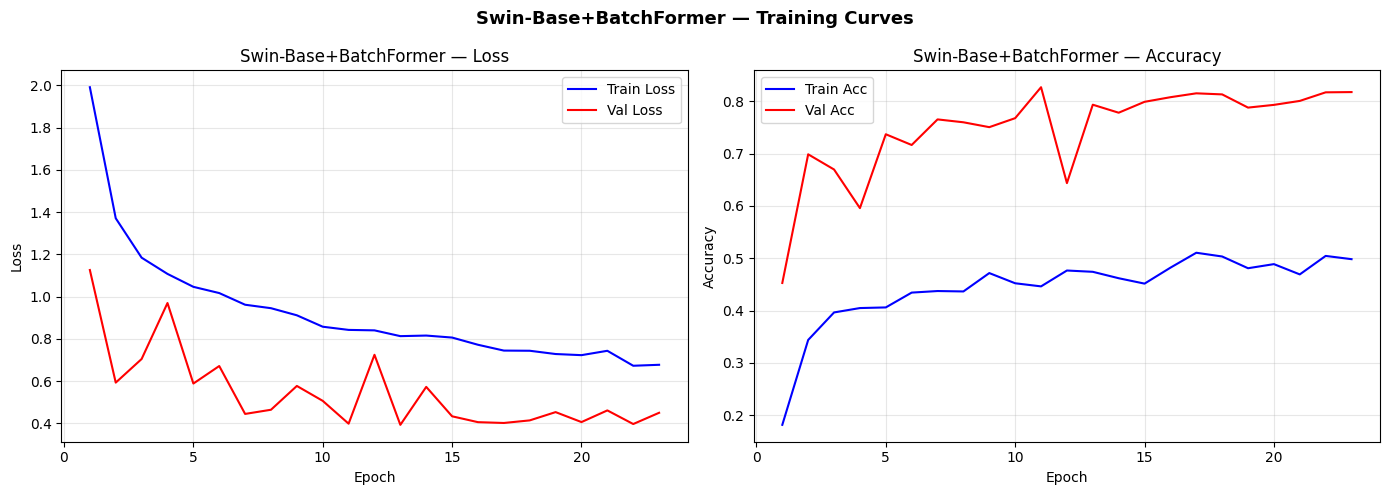

Saved: /kaggle/working/xai_medical_imaging/results/Swin-Base+BatchFormer_training_curves.png

Overfitting diagnosis:
   Best train acc : 0.5105
   Best val acc   : 0.8273
   Train-val gap  : -0.3167  (✔ acceptable gap)

── Swin-Base + BatchFormer Evaluation ──


  Val  :   0%|          | 0/198 [00:00<?, ?it/s]


  Swin-Base+BatchFormer — Final Validation Results
  Val Loss     : 0.3930
  Val Accuracy : 0.7938  (79.38%)

  Classification Report:
              precision    recall  f1-score   support

         MEL     0.6770    0.6956    0.6862      1130
          NV     0.9173    0.8099    0.8603      3219
         BCC     0.8392    0.8857    0.8618       831
          AK     0.6204    0.7834    0.6925       217
         BKL     0.6532    0.7409    0.6943       656
          DF     0.7937    0.8333    0.8130        60
        VASC     0.7468    0.9365    0.8310        63
         SCC     0.4539    0.8471    0.5911       157

    accuracy                         0.7938      6333
   macro avg     0.7127    0.8165    0.7538      6333
weighted avg     0.8123    0.7938    0.7990      6333



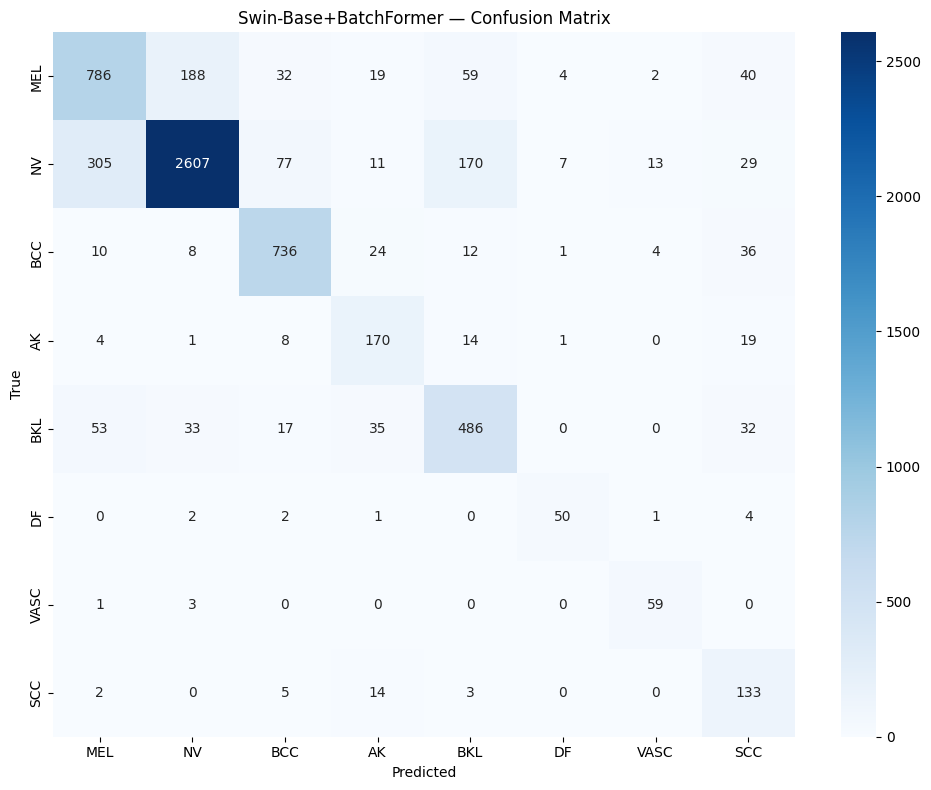

Saved: /kaggle/working/xai_medical_imaging/results/Swin-Base+BatchFormer_confusion_matrix.png


In [10]:
# ============================================================
# 8. EVALUATION & RESULTS
# ============================================================

def safe_name(model_name):
    return model_name.replace('/', '_').replace(' ', '_')


def plot_training_curves(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history['train_loss']) + 1)

    ax1.plot(ep, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(ep, history['val_loss'],   'r-', label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{model_name} — Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(ep, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(ep, history['val_acc'],   'r-', label='Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{model_name} — Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} — Training Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f'{safe_name(model_name)}_training_curves.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

    gap = max(history['train_acc']) - max(history['val_acc'])
    print(f"\nOverfitting diagnosis:")
    print(f"   Best train acc : {max(history['train_acc']):.4f}")
    print(f"   Best val acc   : {max(history['val_acc']):.4f}")
    print(f"   Train-val gap  : {gap:.4f}  "
          f"({'⚠ overfitting detected' if gap > 0.10 else '✔ acceptable gap'})")


def evaluate_model(model, loader, model_name, device=DEVICE):
    criterion = FocalLoss()
    val_loss, val_acc, preds, labels = validate(model, loader, criterion, device)

    print(f"\n{'='*60}")
    print(f"  {model_name} — Final Validation Results")
    print(f"{'='*60}")
    print(f"  Val Loss     : {val_loss:.4f}")
    print(f"  Val Accuracy : {val_acc:.4f}  ({val_acc*100:.2f}%)")
    print(f"\n  Classification Report:")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f'{safe_name(model_name)}_confusion_matrix.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

    return {'val_loss': val_loss, 'val_acc': val_acc, 'preds': preds, 'labels': labels}


# --- ConvNeXt-Base ---
# print("── ConvNeXt-Base Training Curves ──")
# plot_training_curves(convnext_history, "ConvNeXt-Base")
# print("\n── ConvNeXt-Base Evaluation ──")
# convnext_results = evaluate_model(convnext_model, val_loader, "ConvNeXt-Base")

# --- Swin-Base + BatchFormer ---
print("\n── Swin-Base + BatchFormer Training Curves ──")
plot_training_curves(swin_history, "Swin-Base+BatchFormer")
print("\n── Swin-Base + BatchFormer Evaluation ──")
swin_results = evaluate_model(swin_model, val_loader, "Swin-Base+BatchFormer")

## 9. Save Models

In [ ]:
# ============================================================
# 9. SAVE MODELS & SUMMARY
# ============================================================

def save_summary(results_dict, save_dir):
    summary = {
        name: {'val_loss': float(r['val_loss']), 'val_acc': float(r['val_acc'])}
        for name, r in results_dict.items()
    }
    path = os.path.join(save_dir, 'hybrid_training_summary.json')
    with open(path, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"Summary saved: {path}")
    return summary


all_results = {
    'ConvNeXt-Base':          convnext_results,
    'Swin-Base+BatchFormer':  swin_results,
}
summary = save_summary(all_results, SAVE_DIR)

print("\n" + "="*60)
print("  TRAINING COMPLETE — Hybrid Models")
print("="*60)
for name, m in summary.items():
    print(f"  {name:28s}  val_acc={m['val_acc']:.4f}  val_loss={m['val_loss']:.4f}")
print(f"\nAll checkpoints in: {SAVE_DIR}")
print("="*60)
print("\n✔ Ready for XAI analysis in demo_xai_medical.ipynb")